In [2]:
!pip install ucimlrepo -q

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# veri seti
dataset = fetch_ucirepo(id=94)
X = dataset.data.features.values
y = dataset.data.targets.values.ravel()

# egitim ve test kumelerine ayirma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"egitim boyutu: {X_train.shape}")
print(f"test boyutu: {X_test.shape}")

egitim boyutu: (3680, 57)
test boyutu: (921, 57)


In [4]:
from tensorflow.keras.callbacks import EarlyStopping

# keras
model_keras = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# model ozeti
model_keras.summary()


model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# modeli egitme
history = model_keras.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)


test_loss, test_acc = model_keras.evaluate(X_test, y_test, verbose=0)
print(f"\nkeras test kaybi: {test_loss:.4f} | test dogrulugu: {test_acc:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073 (4.19 KB)

 Trainable params: 1,073 (4.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6590 - loss: 0.6458 - val_accuracy: 0.8030 - val_loss: 0.5135
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7812 - loss: 0.4893 - val_accuracy: 0.8859 - val_loss: 0.3850
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8482 - loss: 0.3981 - val_accuracy: 0.9062 - val_loss: 0.3008
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8784 - loss: 0.3267 - val_accuracy: 0.9171 - val_loss: 0.2565
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8974 - loss: 0.2997 - val_accuracy: 0.9266 - val_loss: 0.2319
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9120 - loss: 0.2663 - val_accuracy: 0.9321 - val_loss: 0.2182
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.2498 - val_accuracy: 0.9348 - val_loss: 0.2132
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9253 - loss: 0.2282 - val_accuracy: 0.9334 - val_loss

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  pytorch tensor formatina donusturme
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# veri yukleme
full_ds = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# ann model
class ANN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model_pt = ANN(X_train.shape[1]).to(device)
print(model_pt)

# kayip fonksiyonu ve optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)

# dogruluk metriki fonksiyonu
def accuracy(logits, targets):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == targets).float().mean()

# egitim dongusu
EPOCHS = 20

for epoch in range(1, EPOCHS + 1):
    model_pt.train()
    train_loss = 0.0
    for data, targets in train_loader:
        data, targets = data.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model_pt(data)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

# dogrulama degerlendirmesi
model_pt.eval()
val_loss, val_correct = 0.0, 0.0
with torch.no_grad():
    for data, targets in val_loader:
        data, targets = data.to(device), targets.to(device)
        logits = model_pt(data)
        val_loss += criterion(logits, targets).item() * data.size(0)
        val_correct += (accuracy(logits, targets) * data.size(0)).item()

val_loss /= len(val_loader.dataset)
val_acc = val_correct / len(val_loader.dataset)
print(f"epoch: {EPOCHS} | val kaybi: {val_loss:.4f} | val dogrulugu: {val_acc:.4f}")

# test seti degerlendirmesi
with torch.no_grad():
    test_logits = model_pt(X_test_tensor.to(device))
    test_loss_pt = criterion(test_logits, y_test_tensor.to(device)).item()
    test_acc_pt = accuracy(test_logits, y_test_tensor.to(device)).item()

print(f"\npytorch test kaybi: {test_loss_pt:.4f} | test dogrulugu: {test_acc_pt:.4f}")

ANN(
  (net): Sequential(
    (0): Linear(in_features=57, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)
epoch: 20 | val kaybi: 0.2487 | val dogrulugu: 0.9144

pytorch test kaybi: 0.1950 | test dogrulugu: 0.9316


In [6]:

t = np.arange(2000)
series = np.sin(0.05 * t) + 0.5 * np.sin(0.011 * t) + np.random.normal(0, 0.1, len(t))
series = series.astype("float32")

WINDOW = 30

def make_windows(data, window):
    X_seq, y_seq = [], []
    for i in range(len(data) - window):
        X_seq.append(data[i:i + window])
        y_seq.append(data[i + window])
    return np.array(X_seq), np.array(y_seq)

X_time, y_time = make_windows(series, WINDOW)

#  egitim ve test ayrilmasi
split_idx = int(0.8 * len(X_time))
X_tr_time, X_te_time = X_time[:split_idx], X_time[split_idx:]
y_tr_time, y_te_time = y_time[:split_idx], y_time[split_idx:]

print(f"X egitim zamansal boyutu: {X_tr_time.shape}")
print(f"X test zamansal boyutu: {X_te_time.shape}")


def build_model(cell="lstm", units=32):
    rnn_layer = layers.LSTM(units) if cell == "lstm" else layers.GRU(units)
    model = keras.Sequential([
        layers.Input(shape=(X_tr_time.shape[1], 1)),
        rnn_layer,
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

# modelleri egime
sonuclar_rnn = {}

for cell_type in ["lstm", "gru"]:
    print(f"\n--- {cell_type.upper()} Modeli Egitiliyor ---")
    model_rnn = build_model(cell=cell_type)
    model_rnn.summary()

    model_rnn.fit(
        X_tr_time,
        y_tr_time,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    mse_val, mae_val = model_rnn.evaluate(X_te_time, y_te_time, verbose=0)
    sonuclar_rnn[cell_type.upper()] = {"MSE": round(mse_val, 4), "MAE": round(mae_val, 4)}

# modellerin test performans karsilastirmasi
rnn_karsilastirma = pd.DataFrame(sonuclar_rnn).T
display(rnn_karsilastirma)

X egitim zamansal boyutu: (1576, 30)
X test zamansal boyutu: (394, 30)

--- LSTM Modeli Egitiliyor ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

...

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0922 - mae: 0.2236 - val_loss: 0.0229 - val_mae: 0.1218
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0227 - mae: 0.1221 - val_loss: 0.0223 - val_mae: 0.1221
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0206 - mae: 0.1157 - val_loss: 0.0216 - val_mae: 0.1207
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0193 - mae: 0.1118 - val_loss: 0.0208 - val_mae: 0.1185
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - mae: 0.1088 - val_loss: 0.0200 - val_mae: 0.1166
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0177 - mae: 0.1064 - val_loss: 0.0193 - val_mae: 0.1149
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0172 - mae: 0.1045 - val_loss: 0.0188 - val_mae: 0.1131
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0166 - mae: 0.1028 - val_loss: 0.0182 - val_mae: 0.1116
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.016

,MSE,MAE
LSTM,0.0119,0.0855
GRU,0.0128,0.0883


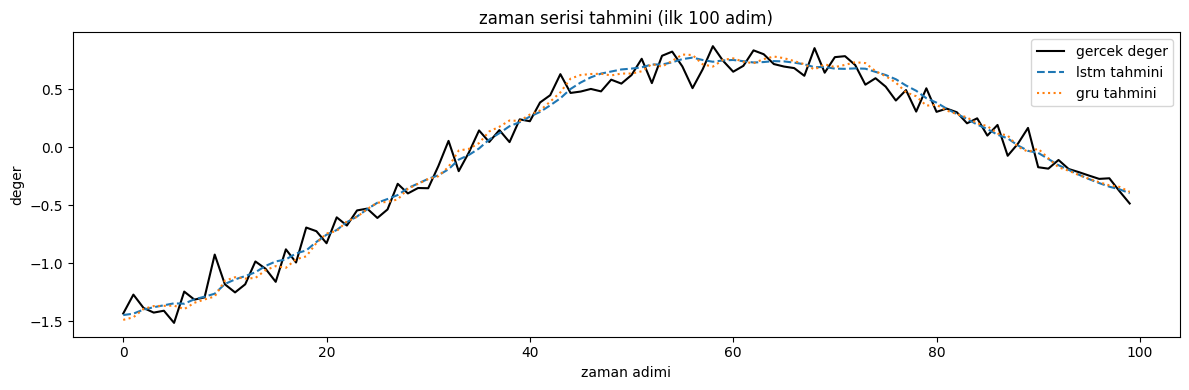

In [7]:
# test kumesinde lstm ve gru tahminleri
model_lstm = build_model(cell="lstm")
model_lstm.fit(X_tr_time, y_tr_time, epochs=20, batch_size=32, verbose=0)
tahmin_lstm = model_lstm.predict(X_te_time, verbose=0)

model_gru = build_model(cell="gru")
model_gru.fit(X_tr_time, y_tr_time, epochs=20, batch_size=32, verbose=0)
tahmin_gru = model_gru.predict(X_te_time, verbose=0)

# ilk 100 adimlik tahmin karsilastirma grafigi
plt.figure(figsize=(12, 4))
plt.plot(y_te_time[:100], label="gercek deger", color="black", lw=1.5)
plt.plot(tahmin_lstm[:100], label="lstm tahmini", color="tab:blue", linestyle="--")
plt.plot(tahmin_gru[:100], label="gru tahmini", color="tab:orange", linestyle=":")
plt.title("zaman serisi tahmini (ilk 100 adim)")
plt.xlabel("zaman adimi")
plt.ylabel("deger")
plt.legend()
plt.tight_layout()
plt.show()